# stochastic-rs — CUDA back-end check on a Colab GPU

Runs the native CUDA tests of `stochastic-rs-stochastic` (the fGN cuFFT + Philox pipeline and the Euler engine kernels) on the notebook's GPU, so the `cuda-native` feature can be validated without a CUDA machine of your own.

Before running: **Runtime → Change runtime type → T4 GPU** (any NVIDIA GPU works). The first cargo build takes 10–20 minutes on Colab's two cores; the tests themselves take seconds.

Cells: 1 GPU + toolkit check · 2 Rust toolchain · 3 clone · 4 native CUDA tests · 5 (optional) CubeCL CUDA runtime · 6 (optional) Python wheel with `device="cuda-native"` · 7 (optional) plots from the GPU.

In [8]:
# 1. The GPU and the CUDA toolkit. The driver's CUDA version (nvidia-smi, top right)
#    should be >= the toolkit's (nvcc): NVRTC emits PTX for the toolkit's version and
#    an older driver cannot JIT it (CUDA_ERROR_UNSUPPORTED_PTX_VERSION). Colab ships
#    them matched; if they differ, see the note at the end.
!nvidia-smi
!nvcc --version | tail -2

Thu Sep  3 15:22:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# 2. Rust (stable, minimal profile). PATH is extended for every later cell.
import os
!curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y --profile minimal > /dev/null
os.environ["PATH"] = "/root/.cargo/bin:" + os.environ["PATH"]
os.environ["CARGO_TERM_COLOR"] = "never"
!cargo --version && rustc --version

info: downloading installer
warn: it looks like you have an existing rustup settings file at:
warn: /root/.rustup/settings.toml
info: profile set to minimal
info: default host tuple is x86_64-unknown-linux-gnu
warn: Updating existing toolchain, profile choice will be ignored
info: syncing channel updates for stable-x86_64-unknown-linux-gnu
info: default toolchain set to stable-x86_64-unknown-linux-gnu
cargo 1.98.1 (797e8a9bc 2026-08-05)
rustc 1.98.1 (48a229cea 2026-09-01)


In [10]:
# 3. The repository. REF is a branch, tag or commit; main is the default.
REF = "main"
!rm -rf stochastic-rs && git clone --quiet --depth 1 --branch {REF} https://github.com/rust-dd/stochastic-rs.git
%cd stochastic-rs
!git log --oneline -1

/content/stochastic-rs/stochastic-rs
c274797 (grafted, HEAD -> main, origin/main, origin/HEAD) chore: build the colab wheel without a virtualenv


In [11]:
# 4. Native CUDA tests: fGN (cuFFT + Philox; shapes, moments against the CPU path,
#    seed reproducibility regardless of launch history) and the Euler engine (GBM
#    moments, CIR positivity, f32/f64 agreement, chunked batches). ~10-20 min to build.
!cargo test -p stochastic-rs-stochastic --features cuda-native --lib -- cuda_native 2>&1 | grep -E "^test |^test result|error|panicked"

   Compiling thiserror v2.0.20
   Compiling thiserror-impl v2.0.20
test euler::tests::devices::cuda_native_chunks_are_bit_identical_to_one_launch ... ok
test noise::fgn::cuda_native::tests::cuda_native_batch_shape ... ok
test noise::fgn::cuda_native::tests::cuda_native_chunks_are_bit_identical_to_one_launch ... ok
test noise::fgn::cuda_native::tests::cuda_native_covariance_structure_matches_cpu ... ok
test noise::fgn::cuda_native::tests::cuda_native_eigenvalues_structural ... ok
test noise::fgn::cuda_native::tests::cuda_native_f32_works ... ok
test noise::fgn::cuda_native::tests::cuda_native_non_power_of_two_n ... ok
test noise::fgn::cuda_native::tests::cuda_native_same_seed_same_paths_regardless_of_history ... ok
test noise::fgn::cuda_native::tests::cuda_native_scale_matches_cpu ... ok
test noise::fgn::cuda_native::tests::cuda_native_single_path_shape ... ok
test euler::tests::devices::cuda_native_backend_matches_the_moments ... ok
test noise::fgn::cuda_native::tests::cuda_native_vari

In [12]:
# 5. (Optional) the CubeCL CUDA runtime as well: the portable kernels on the same GPU,
#    plus the Metal ≡ CubeCL-style agreement checks that exist for CUDA. Adds a few
#    minutes of build time. Set RUN_CUBECL = True to run.
RUN_CUBECL = False
if RUN_CUBECL:
    !cargo test -p stochastic-rs-stochastic --features cuda-native,cubecl-cuda --lib -- cuda_native cubecl 2>&1 | grep -E "^test |^test result|error|panicked"

In [13]:
# 6. (Optional) the Python module with the CUDA back-end: builds the wheel (release,
#    20-30 min on Colab; maturin needs an explicit interpreter here because Colab has no venv) and runs the device-related pytest cases with
#    device="cuda-native". Set RUN_PYTHON = True to skip the 20-30 minute wheel build.
RUN_PYTHON = True
if RUN_PYTHON:
    !pip -q install maturin pytest numpy
    # No virtualenv on Colab, so build the wheel for the notebook's interpreter and pip-install it.
    !maturin build --release --features cuda-native --interpreter python3 --out dist 2>&1 | tail -2
    !pip -q install --force-reinstall --no-deps dist/*.whl
    !python -m pytest -q stochastic-rs-py/tests/test_stochastic.py -k "device or euler_paths or probe" 2>&1 | tail -8
    import importlib
    import numpy as np
    sr = importlib.import_module("stochastic_rs")
    print(sr.probe_device("cuda-native"))
    paths = sr.euler_paths("gbm", [0.05, 0.2], 100.0, 253, 1.0, 20_000, seed=7, device="cuda-native")
    print(paths.shape, paths.dtype, "terminal mean / forward =", paths[:, -1].mean() / (100.0 * np.exp(0.05)))


    Finished `release` profile [optimized] target(s) in 10m 37s
📦 Built wheel for CPython 3.13 to dist/stochastic_rs-3.0.0rc0-cp313-cp313-manylinux_2_35_x86_64.whl
....                                                                     [100%]
{'backend': 'CudaNative', 'name': 'Tesla T4', 'precisions': ['f32', 'f64'], 'ordinal': 0}
(20000, 253) float64 terminal mean / forward = 1.0014889456702245


{'backend': 'CudaNative', 'name': 'Tesla T4', 'precisions': ['f32', 'f64'], 'ordinal': 0}


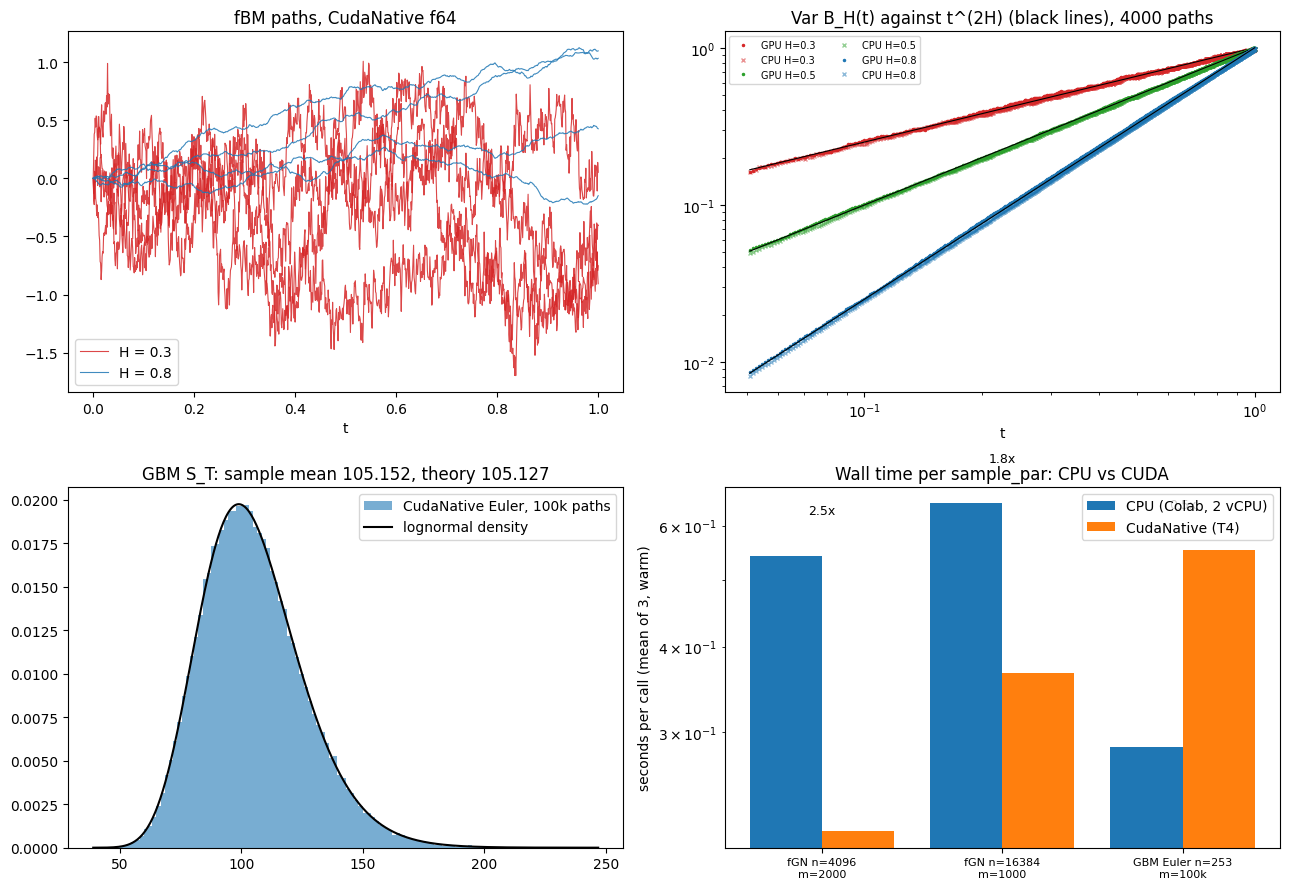

In [14]:
# 7. Plots from the GPU (needs the wheel from cell 6, RUN_PYTHON = True):
#    fBM paths, the t^(2H) variance law GPU vs CPU, the GBM terminal law against
#    the lognormal density, and wall time per call CPU vs CUDA.
if RUN_PYTHON:
    import importlib, time
    import numpy as np
    import matplotlib.pyplot as plt
    sr = importlib.import_module("stochastic_rs")
    print(sr.probe_device("cuda-native"))
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) fBM paths for two Hurst exponents, sampled on the GPU (f64).
    ax = axes[0, 0]
    n = 1024
    grid = np.linspace(0.0, 1.0, n)
    for h, color in ((0.3, "tab:red"), (0.8, "tab:blue")):
        paths = sr.PyFbm(h, n, t=1.0, seed=3, device="cuda-native").sample_par(4)
        for k, path in enumerate(paths):
            ax.plot(grid, path, color=color, lw=0.8, alpha=0.85, label=f"H = {h}" if k == 0 else None)
    ax.set_title("fBM paths, CudaNative f64")
    ax.set_xlabel("t")
    ax.legend()

    # (b) Var B_H(t) = t^(2H): GPU dots, CPU crosses, theory lines.
    ax = axes[0, 1]
    m = 4000
    keep = grid > 0.05
    for h, color in ((0.3, "tab:red"), (0.5, "tab:green"), (0.8, "tab:blue")):
        gpu = sr.PyFbm(h, n, t=1.0, seed=11, device="cuda-native").sample_par(m).var(axis=0)
        cpu = sr.PyFbm(h, n, t=1.0, seed=11, device="cpu").sample_par(m).var(axis=0)
        ax.loglog(grid[keep], gpu[keep], ".", color=color, ms=3, label=f"GPU H={h}")
        ax.loglog(grid[keep], cpu[keep], "x", color=color, ms=3, alpha=0.5, label=f"CPU H={h}")
        ax.loglog(grid[keep], grid[keep] ** (2 * h), "k-", lw=0.8)
    ax.set_title("Var B_H(t) against t^(2H) (black lines), 4000 paths")
    ax.set_xlabel("t")
    ax.legend(fontsize=7, ncol=2)

    # (c) GBM terminal value from the Euler engine against the lognormal density.
    ax = axes[1, 0]
    mu, sigma, s0, horizon = 0.05, 0.2, 100.0, 1.0
    terminal = sr.euler_paths("gbm", [mu, sigma], s0, 253, horizon, 100_000, seed=7, device="cuda-native")[:, -1]
    ax.hist(terminal, bins=120, density=True, alpha=0.6, label="CudaNative Euler, 100k paths")
    x = np.linspace(terminal.min(), terminal.max(), 400)
    mlog = np.log(s0) + (mu - 0.5 * sigma**2) * horizon
    slog = sigma * np.sqrt(horizon)
    ax.plot(x, np.exp(-(np.log(x) - mlog) ** 2 / (2 * slog**2)) / (x * slog * np.sqrt(2 * np.pi)), "k-", label="lognormal density")
    ax.set_title(f"GBM S_T: sample mean {terminal.mean():.3f}, theory {s0 * np.exp(mu * horizon):.3f}")
    ax.legend()

    # (d) wall time per call, CPU (Colab's two cores) against the T4; warm calls.
    ax = axes[1, 1]
    def timed(fn, warm=1, reps=3):
        for _ in range(warm):
            fn()
        start = time.perf_counter()
        for _ in range(reps):
            fn()
        return (time.perf_counter() - start) / reps
    cases = {
        "fGN n=4096\nm=2000": lambda d: sr.PyFgn(0.7, 4096, t=1.0, seed=1, device=d).sample_par(2000),
        "fGN n=16384\nm=1000": lambda d: sr.PyFgn(0.7, 16384, t=1.0, seed=1, device=d).sample_par(1000),
        "GBM Euler n=253\nm=100k": lambda d: sr.euler_paths("gbm", [0.05, 0.2], 100.0, 253, 1.0, 100_000, seed=1, device=d),
    }
    labels, cpu_s, gpu_s = [], [], []
    for name, fn in cases.items():
        labels.append(name)
        cpu_s.append(timed(lambda: fn("cpu")))
        gpu_s.append(timed(lambda: fn("cuda-native")))
    xs = np.arange(len(labels))
    ax.bar(xs - 0.2, cpu_s, 0.4, label="CPU (Colab, 2 vCPU)")
    ax.bar(xs + 0.2, gpu_s, 0.4, label="CudaNative (T4)")
    for i, (c, g) in enumerate(zip(cpu_s, gpu_s)):
        ax.text(i, max(c, g) * 1.15, f"{c / g:.1f}x", ha="center", fontsize=9)
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yscale("log")
    ax.set_ylabel("seconds per call (mean of 3, warm)")
    ax.set_title("Wall time per sample_par: CPU vs CUDA")
    ax.legend()
    plt.tight_layout()
    plt.show()


## Reading the result

Every `cuda_native*` test prints `ok` and the summary line ends in `0 failed`. Two things are worth a look if something is red:

- `CUDA_ERROR_UNSUPPORTED_PTX_VERSION` on module load: the toolkit (nvcc) is newer than the driver. Either pick a runtime whose versions match, or install the toolkit matching `nvidia-smi`'s CUDA version (`apt-get install cuda-toolkit-12-x`) and rerun cell 4.
- `device unavailable: CudaContext: ...`: no GPU in this runtime. Change the runtime type to a GPU and run from cell 1.

The same commands run on any CUDA machine; `STOCHASTIC_RS_DEVICE=n` picks the GPU when there are several.